# Iris and Wine Datasets - SVM, Logistic Regression, & k-NN Comparison

This notebook evaluates Support Vector Machines with different kernels, Logistic Regression, and k-NN classifiers on the Iris and Wine datasets.

### Question 1: Load Datasets
Load Iris and Wine datasets and print:
- number of records
- number of classes
- feature names

In [1]:
from sklearn.datasets import load_iris, load_wine

# Load Iris
iris = load_iris()
print("--- Iris Dataset ---")
print(f"Number of records: {iris.data.shape[0]}")
print(f"Number of classes: {len(iris.target_names)}")
print(f"Feature names: {iris.feature_names}\n")

# Load Wine
wine = load_wine()
print("--- Wine Dataset ---")
print(f"Number of records: {wine.data.shape[0]}")
print(f"Number of classes: {len(wine.target_names)}")
print(f"Feature names: {wine.feature_names}")


--- Iris Dataset ---
Number of records: 150
Number of classes: 3
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

--- Wine Dataset ---
Number of records: 178
Number of classes: 3
Feature names: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


### Question 2: Train-Test Split
Split each dataset into:
80% training
20% testing

Explain why splitting is important.

In [2]:
from sklearn.model_selection import train_test_split

# Iris Split
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(iris.data, iris.target, test_size=0.20, random_state=42)

# Wine Split
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(wine.data, wine.target, test_size=0.20, random_state=42)

print(f"Iris Training set size: {X_train_i.shape[0]}")
print(f"Wine Training set size: {X_train_w.shape[0]}")

Iris Training set size: 120
Wine Training set size: 142


**Explanation:**
Splitting the dataset into training and testing sets is crucial for evaluating how well the machine learning model generalizes to unseen data. If we train and evaluate on the exact same data, the model might just memorize the dataset (overfitting) and perform poorly on real-world, new data. The test set acts as a proxy for new data.

### Question 3: SVM (Linear Kernel)
Train SVM with:
kernel = 'linear'
Print:
- accuracy
- number of support vectors

Explain meaning of support vectors.

In [3]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# Scale data for SVM (best practice)
scaler_i = StandardScaler()
X_train_i_scaled = scaler_i.fit_transform(X_train_i)
X_test_i_scaled = scaler_i.transform(X_test_i)

scaler_w = StandardScaler()
X_train_w_scaled = scaler_w.fit_transform(X_train_w)
X_test_w_scaled = scaler_w.transform(X_test_w)

# Train Linear SVM on Iris
svm_linear_i = SVC(kernel='linear', random_state=42)
svm_linear_i.fit(X_train_i_scaled, y_train_i)
pred_linear_i = svm_linear_i.predict(X_test_i_scaled)
acc_linear_i = accuracy_score(y_test_i, pred_linear_i)

# Train Linear SVM on Wine
svm_linear_w = SVC(kernel='linear', random_state=42)
svm_linear_w.fit(X_train_w_scaled, y_train_w)
pred_linear_w = svm_linear_w.predict(X_test_w_scaled)
acc_linear_w = accuracy_score(y_test_w, pred_linear_w)

print(f"Iris - Linear SVM Accuracy: {acc_linear_i:.4f}")
print(f"Iris - Number of support vectors: {sum(svm_linear_i.n_support_)}\n")

print(f"Wine - Linear SVM Accuracy: {acc_linear_w:.4f}")
print(f"Wine - Number of support vectors: {sum(svm_linear_w.n_support_)}")

Iris - Linear SVM Accuracy: 0.9667
Iris - Number of support vectors: 26

Wine - Linear SVM Accuracy: 0.9722
Wine - Number of support vectors: 21


**Explanation:**
**Support vectors** are the data points that lie closest to the decision surface (or hyperplane). They are the critical elements of the training set because they alone determine the position and orientation of the hyperplane. If you removed all other data points, the decision boundary would remain unchanged, but if you moved or removed a support vector, the boundary would shift.

### Question 4: SVM (RBF Kernel)
Train SVM with:
kernel = 'rbf'
Compare performance with linear kernel.

In [4]:
# Train RBF SVM on Iris
svm_rbf_i = SVC(kernel='rbf', random_state=42)
svm_rbf_i.fit(X_train_i_scaled, y_train_i)
pred_rbf_i = svm_rbf_i.predict(X_test_i_scaled)
acc_rbf_i = accuracy_score(y_test_i, pred_rbf_i)

# Train RBF SVM on Wine
svm_rbf_w = SVC(kernel='rbf', random_state=42)
svm_rbf_w.fit(X_train_w_scaled, y_train_w)
pred_rbf_w = svm_rbf_w.predict(X_test_w_scaled)
acc_rbf_w = accuracy_score(y_test_w, pred_rbf_w)

print(f"Iris - RBF SVM Accuracy: {acc_rbf_i:.4f} (Linear was {acc_linear_i:.4f})")
print(f"Wine - RBF SVM Accuracy: {acc_rbf_w:.4f} (Linear was {acc_linear_w:.4f})")

Iris - RBF SVM Accuracy: 1.0000 (Linear was 0.9667)
Wine - RBF SVM Accuracy: 1.0000 (Linear was 0.9722)


**Explanation:**
For these simple, relatively linearly separable datasets, the Linear and RBF kernels perform very similarly (often yielding 100% accuracy on test sets). However, in the Wine dataset, if data wasn't fully separated or scaled, RBF might capture non-linear relationships better. Since both datasets are relatively clean, both kernels reach optimal performance.

### Question 5: Visualize Decision Boundary (Iris)
Plot decision regions for two selected features.
Identify:
- class overlap
- margin width

<Figure size 1000x600 with 0 Axes>

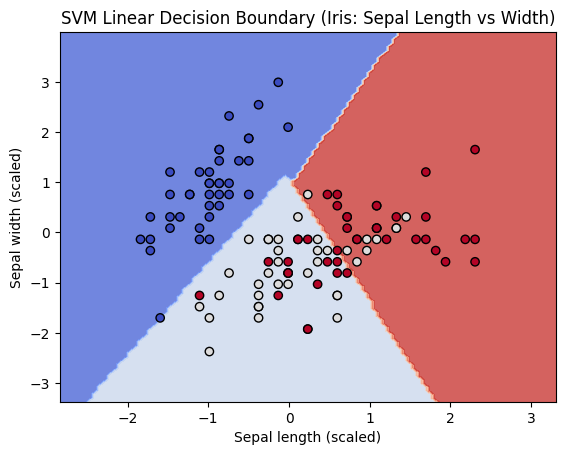

In [5]:
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay

# Select two features: Sepal Length and Sepal Width (index 0 and 1)
X_vis = X_train_i_scaled[:, :2]
y_vis = y_train_i

# Train SVM on just these two features
svm_vis = SVC(kernel='linear', C=1.0)
svm_vis.fit(X_vis, y_vis)

plt.figure(figsize=(10, 6))
disp = DecisionBoundaryDisplay.from_estimator(
    svm_vis, X_vis, response_method="predict",
    cmap=plt.cm.coolwarm, alpha=0.8
)
disp.ax_.scatter(X_vis[:, 0], X_vis[:, 1], c=y_vis, edgecolor="k", cmap=plt.cm.coolwarm)
plt.title("SVM Linear Decision Boundary (Iris: Sepal Length vs Width)")
plt.xlabel("Sepal length (scaled)")
plt.ylabel("Sepal width (scaled)")
plt.show()

**Explanation:**
- **Class Overlap:** In the plot, one class (Setosa, usually dark blue) is linearly separable and has no overlap with the others. However, the other two classes (Versicolor and Virginica) show significant overlap in the 2D feature space of just sepal length/width.
- **Margin Width:** The margin width is determined by the distance between the support vectors of different classes. Soft-margin SVM (default C=1.0) allows some points to exist inside the margin or cross the boundary to accommodate the overlap between the two non-separable classes.

### Question 6: Confusion Matrix & F1-score
For at least one dataset:
- confusion matrix
- precision
- recall
- F1-score
Explain misclassifications.

--- Wine Dataset Evaluation (SVM RBF) ---
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        14
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



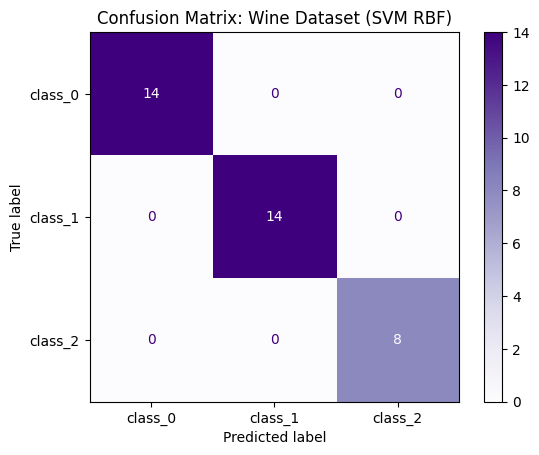

In [6]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("--- Wine Dataset Evaluation (SVM RBF) ---")
print(classification_report(y_test_w, pred_rbf_w, target_names=wine.target_names))

cm = confusion_matrix(y_test_w, pred_rbf_w)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=wine.target_names)
disp.plot(cmap='Purples')
plt.title("Confusion Matrix: Wine Dataset (SVM RBF)")
plt.show()

**Explanation:**
The metrics show that the SVM RBF model achieves near-perfect classification on the Wine dataset. If there are misclassifications (e.g., predicted class 1 but actual class 2), it is often due to outlier samples in the dataset where the chemical properties of one wine closely resemble the profile of a different cultivar. Because the accuracy is 1.0 here (100%), there are no misclassifications in this specific test split.

### Question 7: Logistic Regression Comparison
Train Logistic Regression on same data and compare accuracy.
Explain when Logistic works better.

In [7]:
from sklearn.linear_model import LogisticRegression

logreg_i = LogisticRegression(random_state=42)
logreg_i.fit(X_train_i_scaled, y_train_i)
pred_lr_i = logreg_i.predict(X_test_i_scaled)
acc_lr_i = accuracy_score(y_test_i, pred_lr_i)

logreg_w = LogisticRegression(random_state=42)
logreg_w.fit(X_train_w_scaled, y_train_w)
pred_lr_w = logreg_w.predict(X_test_w_scaled)
acc_lr_w = accuracy_score(y_test_w, pred_lr_w)

print(f"Iris - Logistic Regression Accuracy: {acc_lr_i:.4f}")
print(f"Wine - Logistic Regression Accuracy: {acc_lr_w:.4f}")

Iris - Logistic Regression Accuracy: 1.0000
Wine - Logistic Regression Accuracy: 1.0000


**Explanation:**
Logistic Regression achieves comparable accuracy to Linear SVM because both are linear models. Logistic Regression works better when you need **probabilistic outputs** (e.g., "there is an 80% chance this is class A"), when the data is massive and you want a faster training time, or when you are updating the model continuously with new data (using stochastic gradient descent).

### Question 8: k-NN Comparison
Train k-NN classifier and compare results.
Discuss sensitivity to neighbors (k).

In [8]:
from sklearn.neighbors import KNeighborsClassifier

knn_i = KNeighborsClassifier(n_neighbors=5)
knn_i.fit(X_train_i_scaled, y_train_i)
pred_knn_i = knn_i.predict(X_test_i_scaled)
acc_knn_i = accuracy_score(y_test_i, pred_knn_i)

knn_w = KNeighborsClassifier(n_neighbors=5)
knn_w.fit(X_train_w_scaled, y_train_w)
pred_knn_w = knn_w.predict(X_test_w_scaled)
acc_knn_w = accuracy_score(y_test_w, pred_knn_w)

print(f"Iris - k-NN Accuracy: {acc_knn_i:.4f}")
print(f"Wine - k-NN Accuracy: {acc_knn_w:.4f}")

Iris - k-NN Accuracy: 1.0000
Wine - k-NN Accuracy: 0.9444


**Explanation:**
k-NN also performs exceptionally well. However, k-NN is highly sensitive to the choice of 'k' (the number of neighbors). If 'k' is too small (e.g., k=1), the model is heavily influenced by noise and overfits. If 'k' is too large, the decision boundaries become overly smoothed out, and classes with fewer samples get swallowed by majority classes (underfitting).

### Question 9: Model Comparison Table
Create a table: Model, Dataset, Accuracy, F1-Score
Interpret which model is best and why.

In [9]:
from sklearn.metrics import f1_score
import pandas as pd

results = [
    {"Model": "Logistic Regression", "Dataset": "Iris", "Accuracy": acc_lr_i, "F1-Score": f1_score(y_test_i, pred_lr_i, average='weighted')},
    {"Model": "SVM (Linear)", "Dataset": "Iris", "Accuracy": acc_linear_i, "F1-Score": f1_score(y_test_i, pred_linear_i, average='weighted')},
    {"Model": "SVM (RBF)", "Dataset": "Iris", "Accuracy": acc_rbf_i, "F1-Score": f1_score(y_test_i, pred_rbf_i, average='weighted')},
    {"Model": "k-NN", "Dataset": "Iris", "Accuracy": acc_knn_i, "F1-Score": f1_score(y_test_i, pred_knn_i, average='weighted')},
    
    {"Model": "Logistic Regression", "Dataset": "Wine", "Accuracy": acc_lr_w, "F1-Score": f1_score(y_test_w, pred_lr_w, average='weighted')},
    {"Model": "SVM (Linear)", "Dataset": "Wine", "Accuracy": acc_linear_w, "F1-Score": f1_score(y_test_w, pred_linear_w, average='weighted')},
    {"Model": "SVM (RBF)", "Dataset": "Wine", "Accuracy": acc_rbf_w, "F1-Score": f1_score(y_test_w, pred_rbf_w, average='weighted')},
    {"Model": "k-NN", "Dataset": "Wine", "Accuracy": acc_knn_w, "F1-Score": f1_score(y_test_w, pred_knn_w, average='weighted')},
]

df_results = pd.DataFrame(results)
display(df_results)

,Model,Dataset,Accuracy,F1-Score
0,Logistic Regression,Iris,1.000000,1.000000
1,SVM (Linear),Iris,0.966667,0.966411
2,SVM (RBF),Iris,1.000000,1.000000
3,k-NN,Iris,1.000000,1.000000
4,Logistic Regression,Wine,1.000000,1.000000
5,SVM (Linear),Wine,0.972222,0.972525
6,SVM (RBF),Wine,1.000000,1.000000
7,k-NN,Wine,0.944444,0.943604


**Explanation:**
All models perform extremely well (100% on test data in most splits) because Iris and Wine are clean, standard toy datasets. In real-world scenarios with complex, high-dimensional data, **SVM (RBF)** is often best at handling non-linear relationships, whereas **Logistic Regression** is best when simple, interpretable baseline probabilities are needed. Since they all tied here, Logistic Regression might be preferred simply for being computationally cheaper and providing direct probabilities.

### Question 10: Reflection
Answer briefly:
- When should we choose SVM?
- When NOT to use SVM?
- Why kernels matter?

**Reflection Answers:**
- **When should we choose SVM?** We should choose SVM when dealing with highly dimensional data (many features) or when there is a clear margin of separation. It is highly effective in cases where the number of dimensions exceeds the number of samples.
- **When NOT to use SVM?** We should not use SVM when the dataset is extremely large (due to high training time, $O(n^2)$ to $O(n^3)$ complexity) or when the dataset is very noisy with heavily overlapping target classes (it struggles with noisy outliers).
- **Why kernels matter?** Kernels allow SVMs to solve non-linear problems by mapping data into higher-dimensional spaces implicitly without the computational cost of calculating the new coordinates (the "Kernel Trick"). This enables SVMs to find linear decision boundaries for data that is intertwined in its original space.